In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from glob import glob 
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

This notebook is to aggregate summaries from the model pred files that contain MRMS data - QPE and precip flag. Used for multiple reasons:

- Used for two verification/stats analyses: the MRMS QPE value and MRMS precip flag (ptype)
- [Maybe] to be used for one atm sci contribution study: identify blowing snow / "Radar-Invisible Winter Hazards" / snow squalls - TBD

- Info / files: 
    - Script used for adding MRMS data to model preds: /home/csutter/DRIVE-clean/weather_events/notebooks/cam_modelpred_QPE.py
    - Where model preds w QPE data are saved: /home/csutter/DRIVE-clean/operational_runs_wMRMS
    - Note that the aggregated stats are compiled in this notebook - NOT from the previous script /home/csutter/DRIVE-clean/weather_events/notebooks/stats_events_modelpred.py

### First read in winter data, which is the same regardless of type of analysis being ran

In [2]:
# Model preds with MRMS data - including QPE estimate (mm/hr) and precip flag (ptype) - are already ran and saved: /home/csutter/DRIVE-clean/operational_runs_wMRMS

ls2024 = glob("/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/*/*/*/*")
ls2025 = glob("/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/*/*/*/*")
ls2026 = glob("/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2026/*/*/*/*")

print(len(ls2025))
files = ls2024 + ls2025 + ls2026
print(len(files))

files_winter = [f for f in files if f.split('/')[-4] in ["12", "01", "02", "03"]] # Filter for winter months
print(len(files_winter))

files_summer = [f for f in files if f.split('/')[-4] in ["06", "07", "08"]] # Filter for summer months
print(len(files_summer))

4462
10768
9554
330


In [28]:
files_summer[100:110]

['/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0245/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0615/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_1100/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0045/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0715/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0200/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0945/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_1115/finalpreds.csv',
 '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_1130/finalpreds.csv',
 

# Aggregate stats summaries, used for a variety of purposes (see code after this)
- Don't need to run again!

In [10]:
# Reference - example code for one file [which we'll incorporate into a larger loop below]
fn = '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/12/17/20241217_0400/finalpreds.csv'
df1 = pd.read_csv(fn)

# print(len(df1))
# display(df1.head(3))
# print(np.unique(df1["precip_class"]))
# df2 = df1[df1["precip_class"] == "Snow"]

df2 =  df1[["precip_class", "select", "img_name","select_prob","qpe_val"]]
# print(len(df2))

df3 = df1[["precip_class", "select", "img_name","select_prob","qpe_val"]].groupby(["precip_class","select"]).agg({
                "img_name": "count",
                "select_prob": "mean",
                "qpe_val": "mean",
            }).rename(columns={"img_name": "count", "select_prob": "avg_predprob", "qpe_val": "avg_qpe"}).reset_index()


df3["predfile"] = fn

datetime = fn.split('/')[-2]
df3["datetime"] = datetime

# print(len(df3))
# display(df3)

2366


### Prepare data (DO NOT RUN AGAIN)
- Ran this for both winter and summer

In [4]:
# Combine all stats from all model preds in one dataframe for analysis
# SAVE OUT, for reference, so we don't have to run this code again, since it will take ~10 min to run

# 1. Create an empty list to act as our storage bucket over all model pred files
all_summaries = []

# 2. Loop through 8,000 files
for fn in files_winter: # Ran for both files_summer and files_winter, changing the to_csv path accordingly
    df1 = pd.read_csv(fn)

    # Aggregation code
    df3 = df1[["precip_class", "select", "img_name", "select_prob", "qpe_val"]] \
        .groupby(["precip_class", "select"]) \
        .agg({
            "img_name": "count",
            "select_prob": "mean",
            "qpe_val": "mean",
        }) \
        .rename(columns={
            "img_name": "count", 
            "select_prob": "avg_predprob", 
            "qpe_val": "avg_qpe"
        }) \
        .reset_index()

    # Add your tracking metadata
    df3["predfile"] = fn
    df3["datetime"] = fn.split('/')[-2]

    # 3. Append this tiny summary DataFrame into tracking list
    all_summaries.append(df3)

# 4. Smash the list of 8,000 small agg DataFrames into one DataFrame
master_df = pd.concat(all_summaries, ignore_index=True)
print(f"Successfully aggregated {len(all_summaries)} files!")
print(f"Master DataFrame has {len(master_df)} rows.")


display(master_df.head(6))

# 5. TO SAVE OUT!
master_df.to_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_byfile_byptype_winter.csv", index=False)

Successfully aggregated 9554 files!
Master DataFrame has 89713 rows.


,precip_class,select,count,avg_predprob,avg_qpe,predfile,datetime
0,Cold Rain,poor_viz,29,0.603948,1.851724,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,Cold Rain,wet,168,0.667010,1.613095,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,dry,4,0.384864,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
3,No Precip,poor_viz,16,0.526784,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
4,No Precip,wet,650,0.663253,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
5,Warm Rain,poor_viz,19,0.554497,0.931579,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


### Summary type: Aggregated by P-Type (weather investigation using MRMS)
- Make summaries using aggregated stats (made above, read in csv)
- Results pasted into slides

In [22]:
df = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_byfile_byptype_winter.csv")


df = df.rename(columns = {"count":"cat_preds_count"})

# add cols to make calculations easier - when we need no recalculate avgs when we cut the analyses different ways. Do this for probs and qpe

df["prob_sum_forcalc"] = df["avg_predprob"]*df["cat_preds_count"]
df["qpe_sum_forcalc"] = df["avg_qpe"]*df["cat_preds_count"]

print(len(df)) # 4/27 89713. Was 72761 before -- have the updated data

89713


In [23]:
df = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_byfile_byptype_winter.csv")


df = df.rename(columns = {"count":"cat_preds_count"})

# add cols to make calculations easier - when we need no recalculate avgs when we cut the analyses different ways. Do this for probs and qpe

df["prob_sum_forcalc"] = df["avg_predprob"]*df["cat_preds_count"]
df["qpe_sum_forcalc"] = df["avg_qpe"]*df["cat_preds_count"]


print(len(df))

df.head(3)

agg = df[["precip_class","select","cat_preds_count","prob_sum_forcalc","qpe_sum_forcalc"]].groupby(["precip_class","select"]).sum().reset_index()

display(agg.head(3))

agg2 = agg[["precip_class","cat_preds_count"]].groupby("precip_class").sum().reset_index() # lump convective rain (small) into warm rain, 11 obs too small to include hail/mixed

# # pd function works in place, replace convective rain with warm rain
# agg.loc[agg["precip_class"=="Convective Rain"], 'precip_class'] = 'precip_class'

# display(agg.head(3))

display(agg2)
print("total in this dataset")
sum(agg2["cat_preds_count"]) # matches w y/n amounts!!


89713


,precip_class,select,cat_preds_count,prob_sum_forcalc,qpe_sum_forcalc
0,Cold Rain,dry,109893,70507.613751,34676.0
1,Cold Rain,poor_viz,37424,18076.466333,45441.3
2,Cold Rain,snow,96133,36268.824338,129661.4


,precip_class,cat_preds_count
0,Cold Rain,1055499
1,Convective Rain,1010
2,Hail/Mixed,11
3,No Precip,18231883
4,Snow,2599454
5,Warm Rain,704523


total in this dataset


22592380

In [24]:
agg2.head(3)

,precip_class,cat_preds_count
0,Cold Rain,1055499
1,Convective Rain,1010
2,Hail/Mixed,11


In [26]:
agg.head(2)

,precip_class,select,cat_preds_count,prob_sum_forcalc,qpe_sum_forcalc
0,Cold Rain,dry,109893,70507.613751,34676.0
1,Cold Rain,poor_viz,37424,18076.466333,45441.3


In [27]:
precip_types = np.unique(agg["precip_class"])

pd.options.mode.chained_assignment = None # default is 'warn'

# Displays results by precip class, just summary displays
for p in precip_types:
    agg_p = agg[agg["precip_class"]==p]


    # ptypes_fordf.append(p)
    # predcounts_fordf.append(total_p)

    # That subsetted ^ df really contains everything we need
    # But just Add columns for insight
    total_p = np.sum(agg_p["cat_preds_count"])
    # Percentage of preds by cat
    agg_p["cat_perc"] = agg_p["cat_preds_count"] / total_p
    # avg predprob
    agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
    # avg qpe
    agg_p["qpe_avg"] = agg_p["qpe_sum_forcalc"] / agg_p["cat_preds_count"]

    agg_p = agg_p.drop(columns = ["prob_sum_forcalc","qpe_sum_forcalc"])

    display(agg_p)


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
0,Cold Rain,dry,109893,0.104115,0.641602,0.315543
1,Cold Rain,poor_viz,37424,0.035456,0.483018,1.214229
2,Cold Rain,snow,96133,0.091078,0.377278,1.348771
3,Cold Rain,snow_severe,26251,0.024871,0.393349,1.828837
4,Cold Rain,wet,785798,0.744480,0.707348,1.579008


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
5,Convective Rain,dry,19,0.018812,0.566544,12.863158
6,Convective Rain,poor_viz,21,0.020792,0.490752,60.857143
7,Convective Rain,wet,970,0.960396,0.721912,21.066392


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
8,Hail/Mixed,dry,3,0.272727,0.586836,0.00
9,Hail/Mixed,poor_viz,1,0.090909,0.434033,0.00
10,Hail/Mixed,snow,2,0.181818,0.667765,0.15
11,Hail/Mixed,snow_severe,1,0.090909,0.571199,0.30
12,Hail/Mixed,wet,4,0.363636,0.845275,48.60


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
13,No Precip,dry,14406695,0.790192,0.695784,0.000004
14,No Precip,poor_viz,492526,0.027015,0.413184,0.000149
15,No Precip,snow,751143,0.041199,0.487925,0.000045
16,No Precip,snow_severe,57149,0.003135,0.426978,0.000000
17,No Precip,wet,2524370,0.138459,0.638529,0.000474


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
18,Snow,dry,594040,0.228525,0.621798,0.089632
19,Snow,poor_viz,68149,0.026217,0.405738,0.781322
20,Snow,snow,857367,0.329826,0.527356,0.639169
21,Snow,snow_severe,400806,0.154189,0.548896,1.289231
22,Snow,wet,679092,0.261244,0.641994,0.500378


,precip_class,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
23,Warm Rain,dry,133065,0.188872,0.641492,0.467620
24,Warm Rain,poor_viz,14285,0.020276,0.460096,1.442352
25,Warm Rain,snow,317,0.000450,0.332968,1.205047
26,Warm Rain,snow_severe,107,0.000152,0.345237,0.990654
27,Warm Rain,wet,556749,0.790250,0.699638,2.299302


In [28]:
# Filter out the warm-weather classes
agg_filtered = agg[~agg["precip_class"].isin(["Convective Rain", "Hail/Mixed"])]
precip_types = np.unique(agg_filtered["precip_class"])

for p in precip_types:
    # Subset for the specific precip type
    agg_p = agg_filtered[agg_filtered["precip_class"] == p].copy()

    # Calculate your metrics
    total_p = np.sum(agg_p["cat_preds_count"])
    agg_p["cat_perc"] = (agg_p["cat_preds_count"] / total_p) * 100
    agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]

    # Select only the columns you want to hand off
    # Note: Replace "select" with whatever your model prediction column is actually named
    df_out = agg_p[["select", "cat_perc", "predprob_avg"]].copy() 

    # Round the numbers so the output is perfectly clean
    df_out["cat_perc"] = df_out["cat_perc"].round(2).astype(str) + "%"
    df_out["predprob_avg"] = df_out["predprob_avg"].round(3)

    # Print the label and the clean table
    print(f"=== {p.upper()} ===")
    print(df_out.to_string(index=False))
    print("\n")

=== COLD RAIN ===
     select cat_perc  predprob_avg
        dry   10.41%         0.642
   poor_viz    3.55%         0.483
       snow    9.11%         0.377
snow_severe    2.49%         0.393
        wet   74.45%         0.707


=== NO PRECIP ===
     select cat_perc  predprob_avg
        dry   79.02%         0.696
   poor_viz     2.7%         0.413
       snow    4.12%         0.488
snow_severe    0.31%         0.427
        wet   13.85%         0.639


=== SNOW ===
     select cat_perc  predprob_avg
        dry   22.85%         0.622
   poor_viz    2.62%         0.406
       snow   32.98%         0.527
snow_severe   15.42%         0.549
        wet   26.12%         0.642


=== WARM RAIN ===
     select cat_perc  predprob_avg
        dry   18.89%         0.641
   poor_viz    2.03%         0.460
       snow    0.04%         0.333
snow_severe    0.02%         0.345
        wet   79.02%         0.700




In [15]:
agg.head(3)

,select,cat_preds_count,prob_sum_forcalc,qpe_sum_forcalc,cat_perc,predprob_avg,qpe_avg
0,dry,657516,478006.145152,45851.2,0.851929,0.726988,0.069734
1,poor_viz,23087,8692.019260,5246.5,0.029913,0.376490,0.227249
2,snow_severe,9,2.218460,41.3,0.000012,0.246496,4.588889


In [29]:
# Didn't use this version for paper bc I think adding the predprob distracted from the discussion but keeping here for reference. 

# 1. Dictionary to rename the raw classes to clean presentation labels
class_mapping = {
    "snow_severe": "Severe snow",
    "snow": "Snow",
    "wet": "Wet",
    "dry": "Dry",
    "poor_viz": "Poor visibility"
}

# The exact order you want the rows to appear in the table
desired_order = ["Severe snow", "Snow", "Wet", "Dry", "Poor visibility"]

# Filter out the warm-weather classes
agg_filtered = agg[~agg["precip_class"].isin(["Convective Rain", "Hail/Mixed"])].copy()

# Rename the values in the 'select' column using the mapping above
agg_filtered["select"] = agg_filtered["select"].map(class_mapping).fillna(agg_filtered["select"])

precip_types = np.unique(agg_filtered["precip_class"])

for p in precip_types:
    # Subset for the specific precip type
    agg_p = agg_filtered[agg_filtered["precip_class"] == p].copy()

    # Calculate metrics for individual rows
    total_p = np.sum(agg_p["cat_preds_count"])
    total_prob_sum = np.sum(agg_p["prob_sum_forcalc"]) # Needed for the weighted average
    
    agg_p["cat_perc"] = (agg_p["cat_preds_count"] / total_p) * 100
    agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
    
    # Calculate the total weighted average probability for this precip type
    weighted_avg_prob = total_prob_sum / total_p

    # Select only the columns you want to hand off
    df_out = agg_p[["select", "cat_perc", "predprob_avg"]].copy() 

    # Force pandas to sort the rows into your specific desired order
    df_out["select"] = pd.Categorical(df_out["select"], categories=desired_order, ordered=True)
    df_out = df_out.sort_values("select")

    # Round and format the numbers as strings for clean printing
    df_out["cat_perc"] = df_out["cat_perc"].round(2).astype(str) + "%"
    df_out["predprob_avg"] = df_out["predprob_avg"].round(3).astype(str)

    # Create the Total row
    total_row = pd.DataFrame([{
        "select": "Total",
        "cat_perc": "100.00%",
        "predprob_avg": str(round(weighted_avg_prob, 3))
    }])

    # Append the total row to the bottom of the table
    df_out = pd.concat([df_out, total_row], ignore_index=True)
    
    # Optional: Rename the columns so the Python printout looks even closer to the final LaTeX
    df_out = df_out.rename(columns={
        "select": "Predicted Class",
        "cat_perc": "Percentage",
        "predprob_avg": "Avg Prob"
    })

    # Print the label and the clean table
    print(f"=== {p.upper()} ===")
    print(df_out.to_string(index=False))
    print("\n")

=== COLD RAIN ===
Predicted Class Percentage Avg Prob
    Severe snow      2.49%    0.393
           Snow      9.11%    0.377
            Wet     74.45%    0.707
            Dry     10.41%    0.642
Poor visibility      3.55%    0.483
          Total    100.00%    0.655


=== NO PRECIP ===
Predicted Class Percentage Avg Prob
    Severe snow      0.31%    0.427
           Snow      4.12%    0.488
            Wet     13.85%    0.639
            Dry     79.02%    0.696
Poor visibility       2.7%    0.413
          Total    100.00%    0.671


=== SNOW ===
Predicted Class Percentage Avg Prob
    Severe snow     15.42%    0.549
           Snow     32.98%    0.527
            Wet     26.12%    0.642
            Dry     22.85%    0.622
Poor visibility      2.62%    0.406
          Total    100.00%    0.579


=== WARM RAIN ===
Predicted Class Percentage Avg Prob
    Severe snow      0.02%    0.345
           Snow      0.04%    0.333
            Wet     79.02%      0.7
            Dry     18.89% 

In [30]:
# Used for dissertation, turned into Latex table

# 1. Dictionary to rename the raw classes to clean presentation labels
class_mapping = {
    "snow_severe": "Severe snow",
    "snow": "Snow",
    "wet": "Wet",
    "dry": "Dry",
    "poor_viz": "Poor visibility"
}

# The exact order you want the rows and columns to appear
desired_order = ["Severe snow", "Snow", "Wet", "Dry", "Poor visibility"]
col_order = ["No Precip", "Warm Rain", "Cold Rain", "Snow"]

# 2. Filter out the warm-weather classes
agg_filtered = agg[~agg["precip_class"].isin(["Convective Rain", "Hail/Mixed"])].copy()

# 3. Rename the values in the 'select' column
agg_filtered["select"] = agg_filtered["select"].map(class_mapping).fillna(agg_filtered["select"])

# 4. Calculate support (total instances per precip class)
support = agg_filtered.groupby("precip_class")["cat_preds_count"].sum()

# 5. Calculate the percentages
totals = agg_filtered.groupby("precip_class")["cat_preds_count"].transform('sum')
agg_filtered["Percentage"] = (agg_filtered["cat_preds_count"] / totals) * 100

# 6. Pivot into the main grid layout
final_table = agg_filtered.pivot(
    index="select", 
    columns="precip_class", 
    values="Percentage"
)

# 7. Reorder rows and columns to match our LaTeX layout
final_table = final_table.reindex(desired_order)
final_table = final_table[col_order]

# 8. Format numbers as percentages (this converts them to strings)
for col in final_table.columns:
    final_table[col] = final_table[col].round(2).astype(str) + "%"

# 9. Create the Support and Total rows
# Formats the support numbers with commas (e.g., "14,423,735")
support_row = [f"{int(support[col]):,}" for col in col_order]
total_row = ["100.00%"] * len(col_order)

# 10. Append them to the dataframe
final_table.loc["Support (n)"] = support_row
final_table.loc["Total"] = total_row

# Reorder the index so Support is at the top and Total is at the bottom
final_index_order = ["Support (n)"] + desired_order + ["Total"]
final_table = final_table.reindex(final_index_order)

final_table.index.name = "Predicted Class"

# Print the final clean table
print(final_table.to_string())

precip_class      No Precip Warm Rain  Cold Rain       Snow
Predicted Class                                            
Support (n)      18,231,883   704,523  1,055,499  2,599,454
Severe snow           0.31%     0.02%      2.49%     15.42%
Snow                  4.12%     0.04%      9.11%     32.98%
Wet                  13.85%    79.02%     74.45%     26.12%
Dry                  79.02%    18.89%     10.41%     22.85%
Poor visibility        2.7%     2.03%      3.55%      2.62%
Total               100.00%   100.00%    100.00%    100.00%


In [36]:
18231883+ 704523 + 1055499 + 2599454

22591359

STATS: MRMS Precip Type (Chi-squared and cramer's V)
- See under "observation-level" code below for more STATS analyses for precip type (The multinomial logistic regression)

In [31]:
print(np.unique(agg["precip_class"])) # note that tropical events already taken out from this dataset, aligning w the work in multinomial logistic regrression later on



['Cold Rain' 'Convective Rain' 'Hail/Mixed' 'No Precip' 'Snow' 'Warm Rain']


In [32]:
# Prepare data in the right format for running chi-squared test and cramer's v stat

# Only keep precip classes we care about
agg = agg[~final_stats_df["precip_class"].isin(["Tropical Convective", "Tropical Stratiform"])]

contingency_table = pd.crosstab(
    index=agg['precip_class'],
    columns=agg['select'],
    values=agg['cat_preds_count'],
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)
contingency_table = contingency_table.fillna(0)
print(contingency_table)

# print(type(contingency_table))

# Run chi-squared
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value:              {p_val:.50f}") # will be TINY simply bc of the amount of observations! 73k datetime runs x 2400 observation instances
print(f"Degrees of Freedom:   {dof}")

# Calculate cramer's V
# Formula: V = sqrt(chi2 / (n * min(columns-1, rows-1)))
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print(f"Cramer's V:           {cramers_v:.3f}")

# Interpretation Guide:
# V < 0.1 : Negligible
# 0.1 - 0.3 : Weak
# 0.3 - 0.5 : Moderate
# V > 0.5 : Strong

NameError: name 'final_stats_df' is not defined

In [31]:
930/18000000*100

0.005166666666666667

### Summary type: Y/N precip
- Very similar to the p type analysis above b/c we're just stepping back one level to do 'No precip' vs all other precip grouped together. It's really just cutting the analysis one step up
- Note: pasted these results into: https://docs.google.com/spreadsheets/d/1y6uwvvZeGvoeKmyOaxigvTKPkUGK8zlPpsu4quD9DoQ/edit?gid=0#gid=0 
- For Stats, see farther down under observation-level analyses

In [3]:
# Read in the agg stats df
# Note that this is the data read in same as the p-type analysis, 

df = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_winter.csv")


df = df.rename(columns = {"count":"cat_preds_count"})

# add cols to make calculations easier - when we need no recalculate avgs when we cut the analyses different ways. Do this for probs and qpe

df["prob_sum_forcalc"] = df["avg_predprob"]*df["cat_preds_count"]
df["qpe_sum_forcalc"] = df["avg_qpe"]*df["cat_preds_count"]

df.head(3)



,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime,prob_sum_forcalc,qpe_sum_forcalc
0,Cold Rain,poor_viz,29,0.603948,1.851724,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,17.514480,53.7
1,Cold Rain,wet,168,0.667010,1.613095,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,112.057657,271.0
2,No Precip,dry,4,0.384864,0.000000,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,1.539457,0.0


In [4]:
# aggregation for summary, grouping all non "no precip" cases together, is what makes this different than the above ptype analyis


df["precip_YN"] = ["Precip" if i != "No Precip" else "No Precip" for i in df["precip_class"]]

agg = df[["precip_YN","select","cat_preds_count","prob_sum_forcalc","qpe_sum_forcalc"]].groupby(["precip_YN","select"]).sum().reset_index()

precip_types = np.unique(agg["precip_YN"])

for p in precip_types:
    agg_p = agg[agg["precip_YN"]==p]

    # Add columns for insight
    total_p = np.sum(agg_p["cat_preds_count"])
    # Percentage of preds by cat
    agg_p["cat_perc"] = agg_p["cat_preds_count"] / total_p
    # avg predprob
    agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
    # avg qpe
    agg_p["qpe_avg"] = agg_p["qpe_sum_forcalc"] / agg_p["cat_preds_count"]

    agg_p = agg_p.drop(columns = ["prob_sum_forcalc","qpe_sum_forcalc"])

    display(agg_p)

/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_p["cat_perc"] = agg_p["cat_preds_count"] / total_p
/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

,precip_YN,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
0,No Precip,dry,11336793,0.785982,0.700849,0.000003
1,No Precip,poor_viz,384865,0.026683,0.412427,0.000134
2,No Precip,snow,526145,0.036478,0.480708,0.000034
3,No Precip,snow_severe,39887,0.002765,0.416361,0.000000
4,No Precip,wet,2136045,0.148092,0.647097,0.000206


/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_p["cat_perc"] = agg_p["cat_preds_count"] / total_p
/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
/tmp/tmp.pNY612F4Nh/ipykernel_4149815/4122867640.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

,precip_YN,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
5,Precip,dry,691721,0.182717,0.630932,0.192719
6,Precip,poor_viz,107152,0.028304,0.440840,1.025721
7,Precip,snow,798902,0.211029,0.507255,0.747043
8,Precip,snow_severe,320011,0.084530,0.512837,1.382214
9,Precip,wet,1867967,0.493420,0.686767,1.462712


#### STATS: Y/N Precip 
- See below under obs-level

### Summary type: Seasonal (summer)
- Summer stats pasted into google sheet - https://docs.google.com/spreadsheets/d/1BAzNDBNxPnCZoSPT3Si7nl9zfSmqt-sXjqYbBgqgQ8I/edit?gid=0#gid=0  
- See also tthat this aligns w/ the ad hoc work for manuscript here: /home/csutter/DRIVE-clean/operational_analysis/notebooks/analysis_summer.ipynb
- note that MRMS isn't actually used for this analysis. Just keeping it here for having summaries together

In [12]:
# Read in the summer dataframe

df = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_ptype_byfile_byptype_summer.csv")
# Note that that csv file was made inside this same notebook at the top.
# Need to check why there 

df = df.rename(columns = {"count":"cat_preds_count"})

# add cols to make calculations easier - when we need no recalculate avgs when we cut the analyses different ways. Do this for probs and qpe

df["prob_sum_forcalc"] = df["avg_predprob"]*df["cat_preds_count"]
df["qpe_sum_forcalc"] = df["avg_qpe"]*df["cat_preds_count"]

df.head(3)


# Similar to the other summaries except that we don't need grouping by p-type (col 'precip_class'), we just want the model preds

agg = df[["select","cat_preds_count","prob_sum_forcalc","qpe_sum_forcalc"]].groupby(["select"]).sum().reset_index()

agg_p = agg

# Add columns for insight
total_p = np.sum(agg_p["cat_preds_count"])
# Percentage of preds by cat
agg_p["cat_perc"] = agg_p["cat_preds_count"] / total_p
# avg predprob
agg_p["predprob_avg"] = agg_p["prob_sum_forcalc"] / agg_p["cat_preds_count"]
# avg qpe
agg_p["qpe_avg"] = agg_p["qpe_sum_forcalc"] / agg_p["cat_preds_count"]

agg_p = agg_p.drop(columns = ["prob_sum_forcalc","qpe_sum_forcalc"])

display(agg_p)

print("seasonally relevant")
print(sum(agg_p[agg_p["select"]!="snow_severe"]["cat_preds_count"]))
print("seasonally not relevant - for stats testing")
print(sum(agg_p[agg_p["select"]=="snow_severe"]["cat_preds_count"]))
print("n trials - for stats testing")
print(sum(agg_p["cat_preds_count"]))


,select,cat_preds_count,cat_perc,predprob_avg,qpe_avg
0,dry,657516,0.851929,0.726988,0.069734
1,poor_viz,23087,0.029913,0.376490,0.227249
2,snow_severe,9,0.000012,0.246496,4.588889
3,wet,91185,0.118146,0.641391,1.087374


seasonally relevant
771788
seasonally not relevant - for stats testing
9
n trials - for stats testing
771797


In [7]:
771797/2

385898.5

In [21]:
# find what the 9 summer examples were! See /home/csutter/DRIVE-clean/operational_analysis/notebooks/analysis_summer.ipynb

,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime,prob_sum_forcalc,qpe_sum_forcalc
0,No Precip,dry,1184,0.721268,0.000676,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000,853.980796,0.8
1,No Precip,wet,1078,0.635638,0.006308,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000,685.217896,6.8
2,Warm Rain,dry,11,0.394291,0.381818,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/12/20240712_2000/finalpreds.csv,20240712_2000,4.337204,4.2


9


,precip_class,select,cat_preds_count,avg_predprob,avg_qpe,predfile,datetime,prob_sum_forcalc,qpe_sum_forcalc
225,Hail/Mixed,snow_severe,1,0.329502,41.3,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/07/10/20240710_2230/finalpreds.csv,20240710_2230,0.329502,41.3
603,No Precip,snow_severe,1,0.247951,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0045/finalpreds.csv,20240620_0045,0.247951,0.0
735,No Precip,snow_severe,1,0.186157,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/06/20/20240620_0630/finalpreds.csv,20240620_0630,0.186157,0.0
1227,No Precip,snow_severe,1,0.193109,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/30/20250730_0800/finalpreds.csv,20250730_0800,0.193109,0.0
1279,No Precip,snow_severe,2,0.291225,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/07/25/20250725_0800/finalpreds.csv,20250725_0800,0.582451,0.0
1381,No Precip,snow_severe,1,0.212560,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/30/20250630_0800/finalpreds.csv,20250630_0800,0.212560,0.0
1509,No Precip,snow_severe,1,0.215572,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/28/20250628_0800/finalpreds.csv,20250628_0800,0.215572,0.0
1616,No Precip,snow_severe,1,0.251157,0.0,/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2025/06/20/20250620_0800/finalpreds.csv,20250620_0800,0.251157,0.0


['I_690_west_of_Exit_5_(Van_Vleck_Rd)__Westbound__Skyline_2108_2024-07-10-22:26:07.jpg', 'Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-00:45:08.jpg', 'Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-06:30:08.jpg', 'Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-30-08:00:39.jpg', 'Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-07-25-07:55:48.jpg', 'East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-07-25-07:55:47.jpg', 'Broad_St_at_Allen_St__Unknown__Skyline_5026_2025-06-30-08:00:43.jpg', 'East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-28-08:03:01.jpg', 'East_Ridge_Rd_at_Hudson_Ave__Unknown__Skyline_5016_2025-06-20-08:02:48.jpg']
I_690_west_of_Exit_5_(Van_Vleck_Rd)__Westbound__Skyline_2108_2024-07-10-22:26:07.jpg
Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-00:45:08.jpg
Cross_Bay_Blvd_@_156_Avenue__Both_Directions__NYSDOT_4616518_2024-06-20-06:30:08.jpg
Broad_St_at_Allen_St__Unknown__Sk

#### STATS: Seaonsal
- Uses exact binomial test
- Uses clopper pearson for CI 

In [3]:
from scipy.stats import binomtest
# Your inputs
n_trials = 771797  # Total summer predictions [ see no]
k_false_positives = 9  # Times it falsely predicted snow
# Run the exact binomial test

# 'two-sided' to get both a floor and a ceiling
result = binomtest(k=k_false_positives, n=n_trials, alternative='two-sided') #alternative='two-sided', use alternative='less' for the one sided test

# Calculate the 99.9% confidence interval
ci = result.proportion_ci(confidence_level=0.999)
print(f"Observed error rate: {(k_false_positives / n_trials) * 100:.6f}%")
print(f"99.9% Lower Confidence Bound: {ci.low * 100:.6f}%")
print(f"99.9% Upper Confidence Bound: {ci.high * 100:.6f}%")

# One sided is probably all we need here, we just wanna know the max error rate

Observed error rate: 0.001166%
99.9% Lower Confidence Bound: 0.000288%
99.9% Upper Confidence Bound: 0.003077%


# Aggregate observation-level summaries. 
- For statistical testing of the above investigations - and also for "radar invisible event" work (for atm sci takeaways) - we will need to have obs-level data
- The above summaries saved out are aggregated at too high of a level
- However we can use the above df (saved out) to identify some files to use (if we dont want to use everything)

### Prepare observation-level dataset (DO NOT RUN AGAIN)

In [5]:
# Combine all observations from all model preds in one dataframe that we can keep re-using for analysis, esp for analyses that require info at the observation level. We already save out certain cuts/summaries in /home/csutter/DRIVE-clean/weather_events/models, but when we need NEW cuts/summaries, don't want to have to re-run this obs-level aggregation code every time. Save it out as parquet! 
# Will take some time to run this code (~10 min), but then in next cell we save the df out as parquet

# Use the files list (made at top of nb) has all the files needed
# for reference print what is in "files"
print(files[0:4])


# 1. Create an empty list to act as our storage bucket over all model pred files
all_summaries = []

# 2. Loop through 8,000 files
# Keep just the cols we need to make the data as small as possible
for fn in files: # Ran for all files for the observation-level dataset (no need to filter to summer vs winter), changing the to_csv path accordingly
    df1 = pd.read_csv(fn)

    # Aggregation code
    df3 = df1[["precip_class", "select", "img_name", "select_prob", "qpe_val"]].copy()

    # Add your tracking metadata
    df3["predfile"] = fn
    df3["datetime"] = fn.split('/')[-2]

    # 3. Append this tiny summary DataFrame into tracking list
    all_summaries.append(df3)

# 4. Smash all modelpred df and cols of interest into one DataFrame
# This is a LARGE dataframe, will save it as parquet
maindf = pd.concat(all_summaries, ignore_index=True)
print(f"Successfully aggregated {len(all_summaries)} files!")
print(f"Main DataFrame has {len(maindf)} rows.")


['/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/12/17/20241217_0400/finalpreds.csv', '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/12/17/20241217_1400/finalpreds.csv', '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/12/17/20241217_1800/finalpreds.csv', '/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2024/12/17/20241217_1200/finalpreds.csv']
Successfully aggregated 10768 files!
Main DataFrame has 25454447 rows.


In [6]:
print(f"Successfully aggregated {len(all_summaries)} files!")
print(f"Main DataFrame has {len(maindf)} rows.")

Successfully aggregated 10768 files!
Main DataFrame has 25454447 rows.


In [14]:
print(len(maindf))

20516345


In [15]:
maindf.head(3)

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


In [7]:
# TO SAVE OUT!

maindf.to_parquet('/home/csutter/DRIVE-clean/weather_events/data/modelfiles_concat_wMRMS/observation_level_data.parquet', engine='pyarrow')
print("Done! You never need to loop through the 8,000 files again x 2400 observations again.")


Done! You never need to loop through the 8,000 files again x 2400 observations again.


### Read in observation-level dataset to build summaries/analyses/statistical runs

In [33]:
# 1. Load the optimized data
import pandas as pd
print("Loading the full dataset...")
full_dataset = pd.read_parquet('/home/csutter/DRIVE-clean/weather_events/data/modelfiles_concat_wMRMS/observation_level_data.parquet') # may take ~25s

Loading the full dataset...


In [34]:
# NEXT: subset to winter months only so that the results align w/ the agg summaries!!

# 1. Extract the year and month strings directly from the datetime column
years = full_dataset['datetime'].str[0:4]
months = full_dataset['datetime'].str[4:6]

# 2. Define the exact strings you want to keep
valid_years = ['2024', '2025', '2026']
valid_months = ['12', '01', '02', '03']

# 3. Apply the subset filter
winter_df = full_dataset[
    (years.isin(valid_years)) & 
    (months.isin(valid_months))
].copy() # .copy() is highly recommended here to prevent SettingWithCopy warnings later on

print(f"Original rows: {len(full_dataset):,}")
print(f"Filtered rows: {len(winter_df):,}")

# old: filtered rows = 18.2M
# new 4/27: 25.5M


Original rows: 25,454,447
Filtered rows: 22,592,380


In [6]:
full_dataset.head(3)

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


In [35]:
winter_df.head(3)

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


In [32]:
print(len(full_dataset))

20516345


#### STATS: Y/N precip - QPE buckets vs proportion of precip model preds

In [6]:
# 1. Add in the "not_dry" class grouping "snow_severe", "snow", "wet", "dry"
full_dataset['cat_precip_YN'] = ["not_dry" if i != "dry" else "dry" for i in full_dataset["select"]]

full_dataset.head(4)

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime,cat_precip_YN
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,not_dry
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,not_dry
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,not_dry
3,No Precip,wet,001_9_(MM_000.56)_WB_at_Doremus_Ave__Westbound...,0.508354,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400,not_dry


Calculating 5-percentile boundaries for active precipitation...
Bucketing QPE values...
Generating plot...


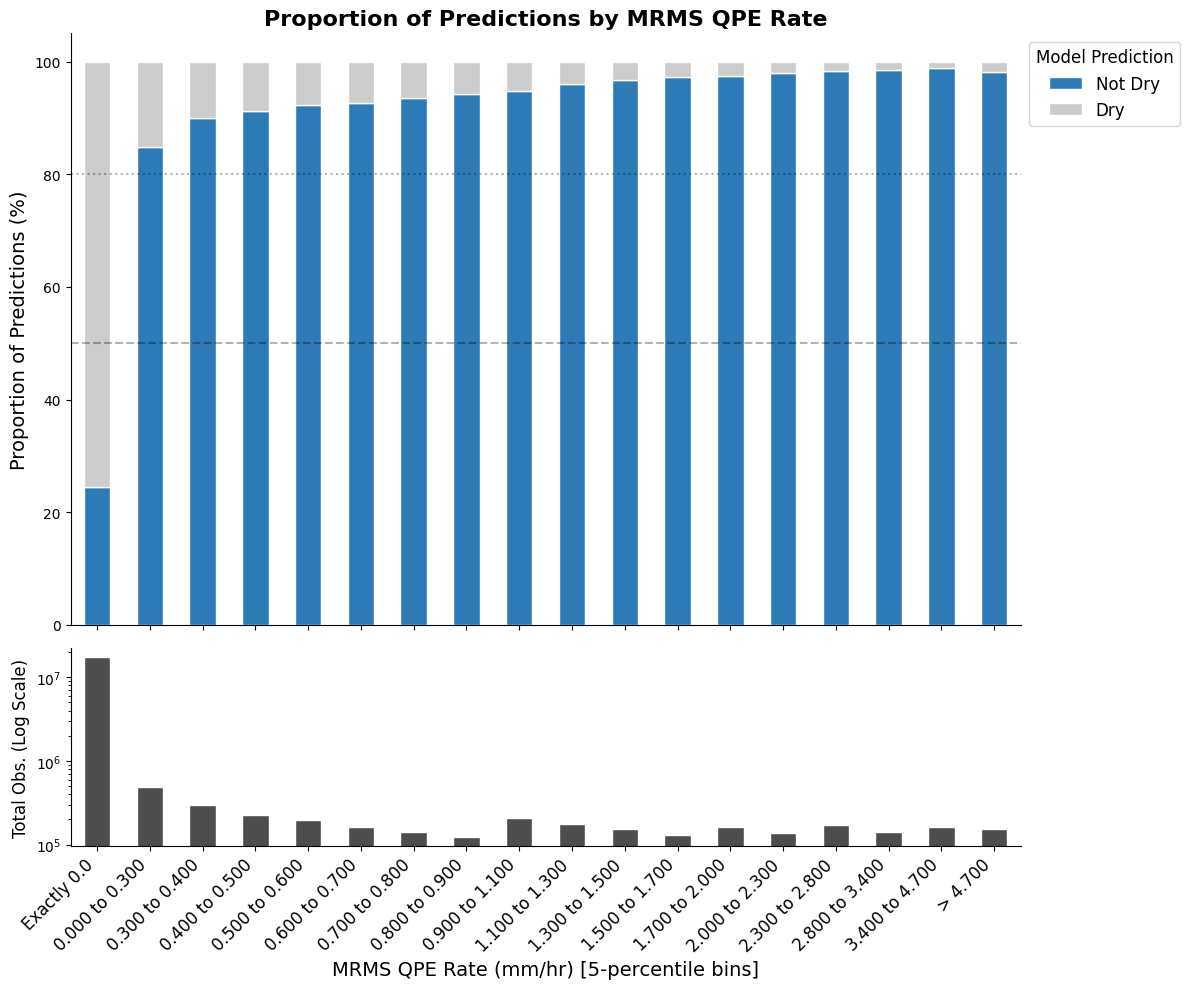

In [4]:
# 1. Calculate dynamic 5-percentile bins (ignoring the zeros)
print("Calculating 5-percentile boundaries for active precipitation...")
precip_only = full_dataset[full_dataset['qpe_val'] > 0.0]['qpe_val']

# Get the 5th, 10th, 15th... 95th percentiles
percentiles = np.percentile(precip_only, np.arange(5, 100, 5))

# Ensure bin edges are strictly unique (just in case multiple percentiles share the same trace value)
raw_bins = [-0.001, 0.0] + percentiles.tolist() + [np.inf]
bins = np.unique(raw_bins).tolist()

# 2. Dynamically generate clean labels for however the percentiles land
labels = ['Exactly 0.0']
for i in range(1, len(bins) - 2):
    labels.append(f"{bins[i]:.3f} to {bins[i+1]:.3f}")
labels.append(f"> {bins[-2]:.3f}")

# 3. Categorize the continuous data into the new percentile buckets
print("Bucketing QPE values...")
full_dataset['qpe_bucket'] = pd.cut(full_dataset['qpe_val'], bins=bins, labels=labels)

# 4. Calculate Proportions and Raw Counts
bucket_counts = full_dataset.groupby(['qpe_bucket', 'cat_precip_YN'], observed=False).size().unstack(fill_value=0)

# Ensure the buckets stay in the exact physical order defined by the labels
bucket_counts = bucket_counts.reindex(labels)

bucket_percentages = bucket_counts.div(bucket_counts.sum(axis=1), axis=0) * 100

# Get the total number of observations per bucket for the bottom chart
total_obs_per_bucket = bucket_counts.sum(axis=1)

# 5. Plotting the Two-Panel Figure
print("Generating plot...")
# Create a figure with 2 subplots. gridspec_kw makes the top plot 3x taller than the bottom one.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- TOP PLOT: The Percentages ---
bucket_percentages[['not_dry', 'dry']].plot(
    kind='bar', stacked=True, color=['#2C7BB6', '#CCCCCC'], ax=ax1, edgecolor='white', legend=False
)
ax1.set_title('Proportion of Predictions by MRMS QPE Rate', fontsize=16, weight='bold')
ax1.set_ylabel('Proportion of Predictions (%)', fontsize=14)

# Add horizontal reference lines
ax1.axhline(50, color='black', linestyle='--', alpha=0.3)
ax1.axhline(80, color='black', linestyle=':', alpha=0.3)

# FIX: Grab the colored bar handles specifically so the axhlines don't hijack the legend
handles, legend_labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], ['Not Dry', 'Dry'], title='Model Prediction', fontsize=12, title_fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))

# Remove x-axis text from the top plot so it doesn't overlap the bottom plot
ax1.set_xticklabels([])
ax1.set_xlabel('') 

# --- BOTTOM PLOT: The Sample Size Distribution ---
# We use a logarithmic scale because the 'Exactly 0.0' bin will dwarf the rest of the data
total_obs_per_bucket.plot(
    kind='bar', color='#4D4D4D', ax=ax2, edgecolor='white', logy=True
)
ax2.set_ylabel('Total Obs. (Log Scale)', fontsize=12)
ax2.set_xlabel('MRMS QPE Rate (mm/hr) [5-percentile bins]', fontsize=14)

# Apply the labels to the bottom x-axis
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)

# Clean up top and right spines for both axes
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# KEEP FOR REFERENCE BC IT SHOWS MORE INFO ABOUT THE BIN GROUPINGS
# Specifically, shows why the 5% (which should be 20 x ticks) results in 17 on our plot (e.g. so many 0.3 QPE examples). It's bc it groups them smartly. 

# 1. Isolate the active precipitation (ignoring the Exactly 0.0s)
precip_only = full_dataset[full_dataset['qpe_val'] > 0.0]['qpe_val']

# 2. Define the exact 20 percentile steps (5%, 10%, 15% ... 100%)
percentile_steps = np.arange(5, 105, 5)

# 3. Calculate the raw, mathematical boundaries
raw_boundaries = np.percentile(precip_only, percentile_steps)

# 4. Print the "Receipts" to show exactly what got merged
print("--- The 20 Raw 5-Percentile Boundaries ---")
previous_value = -1

for step, boundary in zip(percentile_steps, raw_boundaries):
    val_str = f"{boundary:.3f} mm/hr"
    
    # If this boundary is identical to the previous one, flag it!
    if boundary == previous_value:
        print(f"{step:3d}th Percentile: {val_str}  <--- TIED! (Merged into previous bucket)")
    else:
        print(f"{step:3d}th Percentile: {val_str}")
        
    previous_value = boundary

# 5. Show the final math
unique_count = len(np.unique(raw_boundaries))
print("-" * 40)
print(f"Total theoretical buckets requested: 20")
print(f"Total buckets lost to ties:        {20 - unique_count}")
print(f"Final number of unique buckets:    {unique_count}")

--- The 20 Raw 5-Percentile Boundaries ---
  5th Percentile: 0.300 mm/hr
 10th Percentile: 0.300 mm/hr  <--- TIED! (Merged into previous bucket)
 15th Percentile: 0.300 mm/hr  <--- TIED! (Merged into previous bucket)
 20th Percentile: 0.400 mm/hr
 25th Percentile: 0.500 mm/hr
 30th Percentile: 0.500 mm/hr  <--- TIED! (Merged into previous bucket)
 35th Percentile: 0.600 mm/hr
 40th Percentile: 0.700 mm/hr
 45th Percentile: 0.800 mm/hr
 50th Percentile: 0.900 mm/hr
 55th Percentile: 1.100 mm/hr
 60th Percentile: 1.300 mm/hr
 65th Percentile: 1.500 mm/hr
 70th Percentile: 1.700 mm/hr
 75th Percentile: 2.000 mm/hr
 80th Percentile: 2.300 mm/hr
 85th Percentile: 2.800 mm/hr
 90th Percentile: 3.400 mm/hr
 95th Percentile: 4.700 mm/hr
100th Percentile: 182.200 mm/hr
----------------------------------------
Total theoretical buckets requested: 20
Total buckets lost to ties:        3
Final number of unique buckets:    17


Generating fixed 0.2 mm/hr bins up to 6.0...
Bucketing QPE values...
Generating plot...


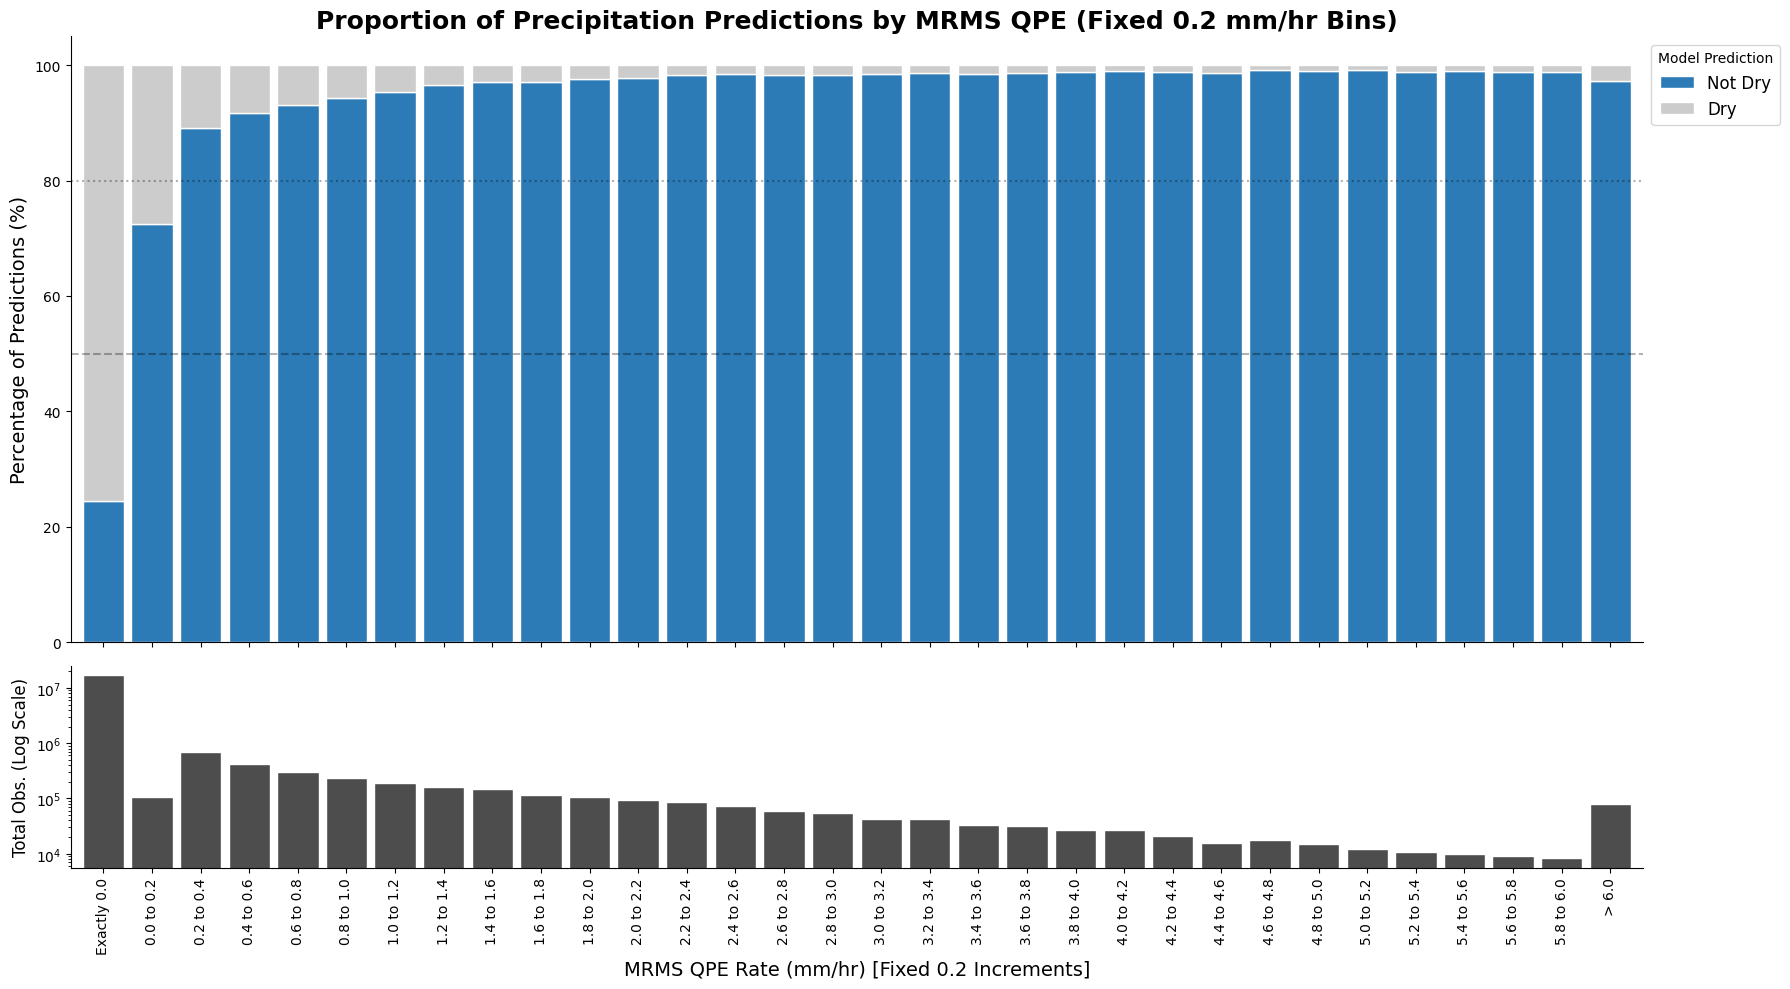

In [54]:
# NOT USING THIS VERSION OF HARDCODED INTERVAL BUCKETS
# But keeping for reference in case someone asks
# Not a great choice b/c bins can be quite small (Note the log scale in distribtution plot at the bottom) This is why percentile binning looks the best bc they're more equal bins

# ==========================================
# 1. SET YOUR PARAMETERS HERE
# ==========================================
MAX_QPE = 6.0      # The highest mm/hr you want to bin explicitly before the ">" catch-all
STEP_SIZE = 0.2    # The size of each bin (e.g., 0.1, 0.2, 0.5)

print(f"Generating fixed {STEP_SIZE} mm/hr bins up to {MAX_QPE}...")

# 2. Define the exact fixed bins dynamically
# We add (STEP_SIZE/2) to the max so np.arange safely includes the exact MAX_QPE value
fixed_steps = np.round(np.arange(STEP_SIZE, MAX_QPE + (STEP_SIZE / 2), STEP_SIZE), 1).tolist()
bins = [-0.001, 0.0] + fixed_steps + [np.inf]

# 3. Generate the labels dynamically
labels = ['Exactly 0.0']
for i in range(1, len(bins) - 2):
    labels.append(f"{bins[i]:.1f} to {bins[i+1]:.1f}")

# The catch-all label now automatically reads whatever you set MAX_QPE to
labels.append(f"> {MAX_QPE:.1f}")

# 4. Categorize the continuous data
print("Bucketing QPE values...")
full_dataset['qpe_bucket'] = pd.cut(full_dataset['qpe_val'], bins=bins, labels=labels)

# 5. Calculate Proportions and Raw Counts
bucket_counts = full_dataset.groupby(['qpe_bucket', 'cat_precip_YN'], observed=False).size().unstack(fill_value=0)
bucket_counts = bucket_counts.reindex(labels)

bucket_percentages = bucket_counts.div(bucket_counts.sum(axis=1), axis=0) * 100
total_obs_per_bucket = bucket_counts.sum(axis=1)

# 6. Plotting the Two-Panel Figure
print("Generating plot...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- TOP PLOT ---
bucket_percentages[['not_dry', 'dry']].plot(
    kind='bar', stacked=True, color=['#2C7BB6', '#CCCCCC'], ax=ax1, edgecolor='white', legend=False, width=0.85
)

# Titles and labels now dynamically read your STEP_SIZE
ax1.set_title(f'Proportion of Precipitation Predictions by MRMS QPE (Fixed {STEP_SIZE} mm/hr Bins)', fontsize=18, weight='bold')
ax1.set_ylabel('Percentage of Predictions (%)', fontsize=14)
ax1.axhline(50, color='black', linestyle='--', alpha=0.3)
ax1.axhline(80, color='black', linestyle=':', alpha=0.3)

handles, legend_labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], ['Not Dry', 'Dry'], title='Model Prediction', fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
ax1.set_xticklabels([])
ax1.set_xlabel('') 

# --- BOTTOM PLOT ---
total_obs_per_bucket.plot(
    kind='bar', color='#4D4D4D', ax=ax2, edgecolor='white', logy=True, width=0.85
)
ax2.set_ylabel('Total Obs. (Log Scale)', fontsize=12)
ax2.set_xlabel(f'MRMS QPE Rate (mm/hr) [Fixed {STEP_SIZE} Increments]', fontsize=14)

# Rotate labels 90 degrees
ax2.set_xticklabels(labels, rotation=90, ha='center', fontsize=10)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# While the bar charts show how accuracy changes in discrete buckets, the logistic regression treats qpe_val as a continuous variable. It calculates the Odds Ratio, which tells you exactly how much more likely the model is to predict "Not Dry" for every incremental increase in rain intensity.
# Takes ~2-3 mins

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. Prepare the Binary Target
# Logistic regression requires 0 or 1. 
# We'll set 'not_dry' as 1 (the event we are predicting)
print("Preparing data for regression...")
full_dataset['target_binary'] = np.where(full_dataset['cat_precip_YN'] == 'not_dry', 1, 0)

# 2. Fit the Model
# Formula: 'target_binary ~ qpe_val' means predict the target using QPE
print("Fitting logistic regression model (this may take a few minutes)...")
logit_results = smf.logit(formula='target_binary ~ qpe_val', data=full_dataset).fit()

# 3. View the Statistical Summary
print(logit_results.summary())

# 4. Calculate Odds Ratios
# The raw coefficients (params) are in log-odds. We exponentiate them to make them readable.
params = logit_results.params
conf = logit_results.conf_int()
conf['OR'] = params
conf.columns = ['5%', '95%', 'Odds Ratio']
odds_ratios = np.exp(conf)

print("\n--- Odds Ratios (Effect Size) ---")
print(odds_ratios)

Preparing data for regression...
Fitting logistic regression model (this may take a few minutes)...
Optimization terminated successfully.
         Current function value: 0.526818
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          target_binary   No. Observations:             20516345
Model:                          Logit   Df Residuals:                 20516343
Method:                           MLE   Df Model:                            1
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.1889
Time:                        22:42:05   Log-Likelihood:            -1.0808e+07
converged:                       True   LL-Null:                   -1.3326e+07
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercep

In [24]:
# 1. Set the increment to 0.2
increment = 0.1

# 2. Get the raw log-coefficient for QPE
qpe_log_coeff = logit_results.params['qpe_val']

# 3. Calculate the scaled Odds Ratio
scaled_OR = np.exp(qpe_log_coeff * increment)

# 4. Calculate Scaled Confidence Intervals
conf_int = logit_results.conf_int().loc['qpe_val']
scaled_lower_ci = np.exp(conf_int[0] * increment)
scaled_upper_ci = np.exp(conf_int[1] * increment)

print(f"--- Results for a {increment} mm/hr jump ---")
print(f"Scaled Odds Ratio: {scaled_OR:.4f}")
print(f"95% CI: [{scaled_lower_ci:.4f}, {scaled_upper_ci:.4f}]")

--- Results for a 0.1 mm/hr jump ---
Scaled Odds Ratio: 1.5406
95% CI: [1.5394, 1.5417]


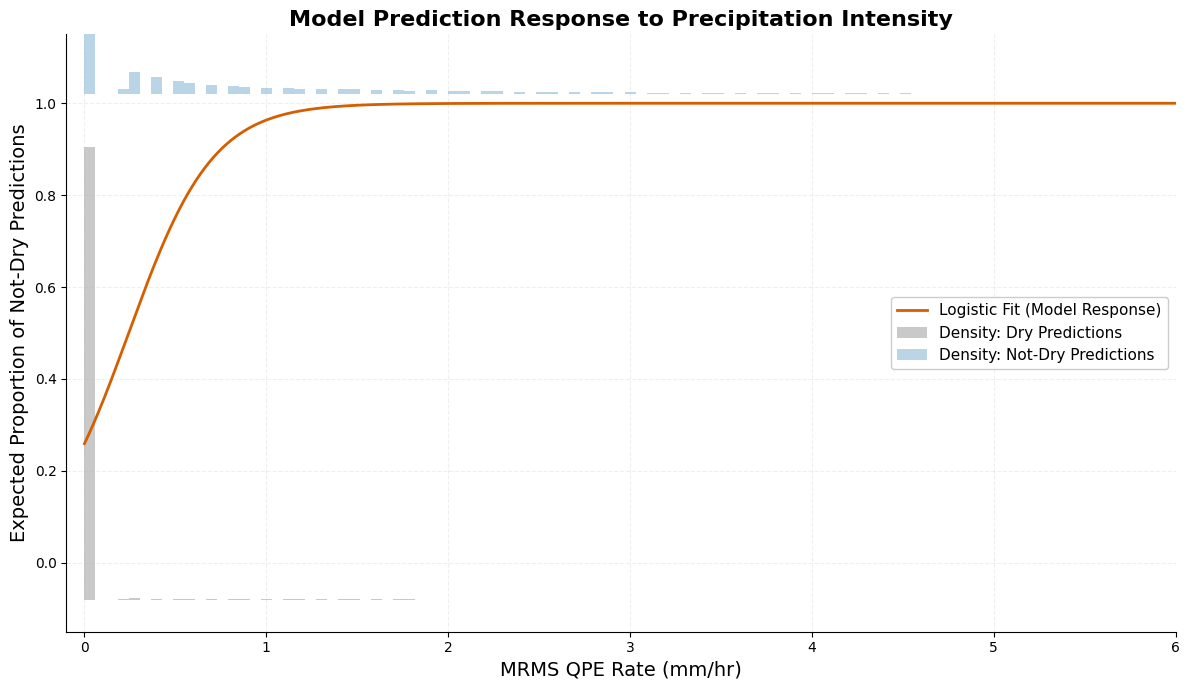

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Math remains the same (The "Truth")
intercept = logit_results.params['Intercept']
qpe_coef = logit_results.params['qpe_val']
x_curve = np.linspace(0, 6.0, 500)
y_curve = 1 / (1 + np.exp(-(intercept + qpe_coef * x_curve)))

# 2. Data for Densities
bins = np.linspace(0, 6.0, 100)
zeros = full_dataset[full_dataset['target_binary'] == 0]['qpe_val']
ones = full_dataset[full_dataset['target_binary'] == 1]['qpe_val']

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# Bottom Density (Dry) - Muted Blue
ax.hist(zeros, bins=bins, weights=np.ones(len(zeros)) / len(zeros), 
        bottom=-0.08, color='#4D4D4D', alpha=0.3, label='Density: Dry Predictions')

# Top Density (Not Dry) - Slate Gray
ax.hist(ones, bins=bins, weights=np.ones(len(ones)) / len(ones), 
        bottom=1.02, color='#1f77b4', alpha=0.3, label='Density: Not-Dry Predictions')

# The Logistic Fit (The Hero of the Plot)
ax.plot(x_curve, y_curve, color='#D55E00', linewidth=2, label='Logistic Fit (Model Response)')

# 4. Final Polish
ax.set_title('Model Prediction Response to Precipitation Intensity', fontsize=16, weight='bold')
ax.set_xlabel('MRMS QPE Rate (mm/hr)', fontsize=14)
ax.set_ylabel('Expected Proportion of Not-Dry Predictions', fontsize=14)

ax.set_xlim(-0.1, 6.0)
ax.set_ylim(-0.15, 1.15) 

# Legend fix: Ensuring labels are clear and distinct
leg = ax.legend(loc='center right', fontsize=11, frameon=True, facecolor='white', framealpha=1)
ax.grid(True, linestyle='--', alpha=0.2)

# Despining for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# 1. Hardcoded Logistic Regression Coefficients
intercept = -1.0502
qpe_coef = 4.3216

# Generate the x-axis values (QPE from 0 to 6 mm/hr)
x_curve = np.linspace(0, 6.0, 500)

# Calculate the logistic S-curve using the exact formula
y_curve = 1 / (1 + np.exp(-(intercept + qpe_coef * x_curve)))

In [10]:
full_dataset['target_binary'] = np.where(full_dataset['cat_precip_YN'] == 'not_dry', 1, 0)

In [25]:
18000000*0.005

90000.0

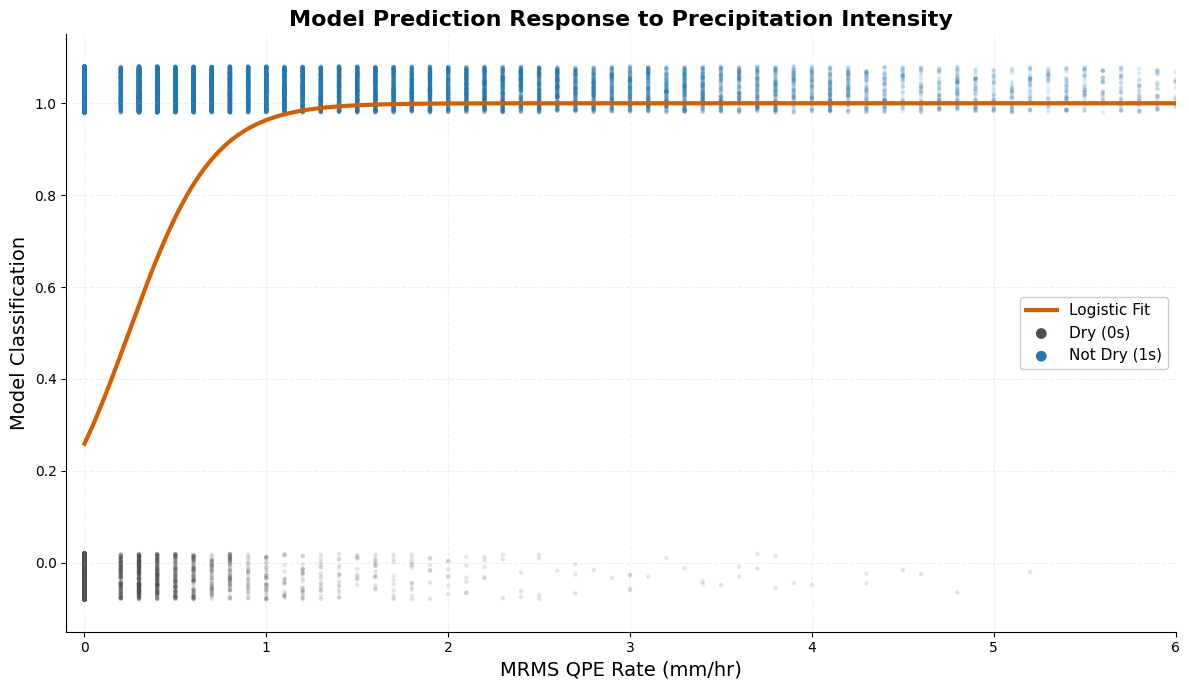

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Hardcoded Math (The "Truth")
intercept = -1.0502
qpe_coef = 4.3216
x_curve = np.linspace(0, 6.0, 500)
y_curve = 1 / (1 + np.exp(-(intercept + qpe_coef * x_curve)))

# 2. Proportional Subsampling and Jitter
# Extract the full arrays first
zeros_full = full_dataset[full_dataset['target_binary'] == 0]['qpe_val']
ones_full = full_dataset[full_dataset['target_binary'] == 1]['qpe_val']

# Sample a tiny fraction (e.g., 1%) to preserve the true real-world ratio
sample_fraction = 0.005 # Adjust this up or down to make the whole plot thicker/thinner
size_zeros = int(len(zeros_full) * sample_fraction)
size_ones = int(len(ones_full) * sample_fraction)

# Grab random samples using the proportional sizes
zeros_sample = np.random.choice(zeros_full, size=size_zeros, replace=False)
ones_sample = np.random.choice(ones_full, size=size_ones, replace=False)

# Add vertical jitter (random noise) so they form a proportional "cloud"
zeros_jitter = np.random.uniform(-0.08, 0.02, size=size_zeros)
ones_jitter = np.random.uniform(0.98, 1.08, size=size_ones)

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the Jittered Scatter Clouds
ax.scatter(zeros_sample, zeros_jitter, color='#4D4D4D', alpha=0.15, s=10, 
           edgecolors='none', label=f'Dry (0s)') #: Dry (n={size_zeros})
ax.scatter(ones_sample, ones_jitter, color='#1f77b4', alpha=0.15, s=10, 
           edgecolors='none', label=f'Not Dry (1s)') #: Not-Dry (n={size_ones})

# The Logistic Fit (The Hero of the Plot)
ax.plot(x_curve, y_curve, color='#D55E00', linewidth=3, label='Logistic Fit')

# 4. Final Polish
ax.set_title('Model Prediction Response to Precipitation Intensity', fontsize=16, weight='bold')
ax.set_xlabel('MRMS QPE Rate (mm/hr)', fontsize=14)
ax.set_ylabel('Model Classification', fontsize=14)

ax.set_xlim(-0.1, 6.0)
ax.set_ylim(-0.15, 1.15) 

# Legend fix: Ensuring labels are clear and distinct
leg = ax.legend(loc='center right', fontsize=11, frameon=True, facecolor='white', framealpha=1)

# Force legend markers to be fully opaque so colors are obvious
for handle in leg.legendHandles:  
    handle.set_alpha(1.0)         # Makes everything 100% solid, not translucent
    
    # Check if the handle is a scatter point before trying to resize it
    if hasattr(handle, 'set_sizes'):
        handle.set_sizes([60])    # Pumps up the dot size (adjust number if you want it even bigger)

ax.grid(True, linestyle='--', alpha=0.2)

# Despining for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

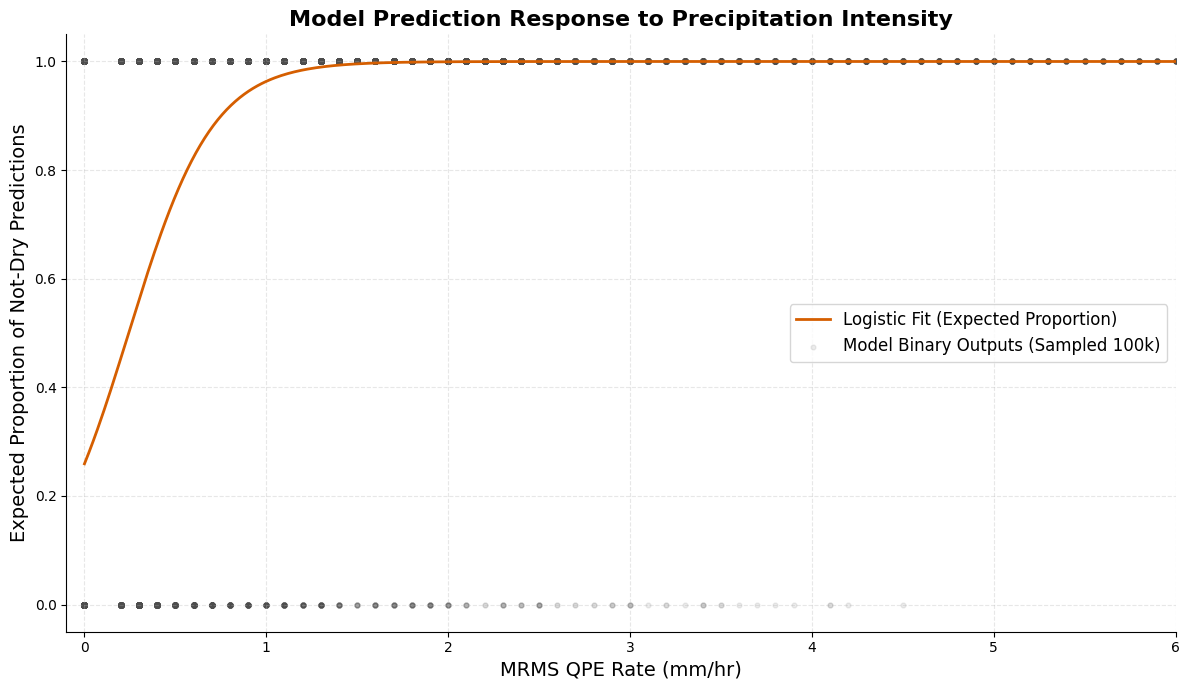

In [20]:
# CURVE FOR REFERENCE 
# Typical 0s/1s but the data is not represented well with dots because it's so heavily skeweed toward the 0 QPE side

import matplotlib.pyplot as plt
import numpy as np

# 1. Re-extract the coefficients from your logit_results object
intercept = logit_results.params['Intercept']
qpe_coef = logit_results.params['qpe_val']

# 2. Generate the smooth S-Curve line
x_curve = np.linspace(0, 6.0, 500)
y_curve = 1 / (1 + np.exp(-(intercept + qpe_coef * x_curve)))

# 3. Sample the data (10k is the 'sweet spot' for visibility vs performance)
sample_data = full_dataset.sample(n=100000, random_state=41)

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# The "Opacity" Scatter - This is what creates the lighter/darker shading
# Lower alpha = more translucent. Overlapping points create the darker 'density' look.
ax.scatter(sample_data['qpe_val'], sample_data['target_binary'], 
           alpha=0.1, color='#4D4D4D', s=12, label='Model Binary Outputs (Sampled 100k)')

# The Logistic Fit
ax.plot(x_curve, y_curve, color='#D55E00', linewidth=2, label='Logistic Fit (Expected Proportion)')

# Labels & Formatting
ax.set_title('Model Prediction Response to Precipitation Intensity', fontsize=16, weight='bold')
ax.set_xlabel('MRMS QPE Rate (mm/hr)', fontsize=14)
ax.set_ylabel('Expected Proportion of Not-Dry Predictions', fontsize=14)

ax.set_xlim(-0.1, 6.0)
ax.set_ylim(-0.05, 1.05)

# Legend Fix: Ensuring the icon is visible even if the plot dots are translucent
leg = ax.legend(loc='center right', fontsize=12)


ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### STATS: MRMS precip type
- Equivalent stats analysis using NYSM as the events done in:  /home/csutter/DRIVE-clean/weather_events/notebooks/investigation_NYSM.ipynb
- Just note data strutcures between the two are different but stats is same

In [3]:
full_dataset.head(3)

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


Multinomial logistic regression

In [7]:
display(full_dataset.head(3))
print(np.unique(full_dataset["precip_class"]))

,precip_class,select,img_name,select_prob,qpe_val,predfile,datetime
0,No Precip,wet,001_9T_(MM_002.00)_WB_E_of_Hackey_Brdg__Westbo...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
1,No Precip,wet,001_9T_(MM_002.74)_EB_at_Duncan_Ave__Eastbound...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400
2,No Precip,wet,001_9T_(MM_003.10)_WB_at_Sip_Ave__Westbound__T...,0.513056,0.0,/home/csutter/DRIVE-clean/operational_runs_wMR...,20241217_0400


['Cold Rain' 'Convective Rain' 'Hail/Mixed' 'No Precip' 'Snow'
 'Tropical Convective' 'Tropical Stratiform' 'Warm Rain']


In [12]:
# OLD WAY (did not use for paper)
import statsmodels.api as sm
import pandas as pd
import numpy as np
import itertools

print("--- Applying Laplace Smoothing & Running Multinomial Regression ---")

# 1. The Laplace Smoothing Step
# Updated to use 'precip_class' and 'select'
events = final_stats_df['precip_class'].unique()
preds = final_stats_df['select'].unique()

laplace_rows = pd.DataFrame(list(itertools.product(events, preds)), columns=['precip_class', 'select'])

smoothed_df = pd.concat([final_stats_df, laplace_rows], ignore_index=True)

# 2. Prepare Y (Outputs)
# IMPORTANT: Verify these exact strings match the unique values in your new 'select' column!
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = smoothed_df['select'].map(pred_mapping)

# 3. Prepare X (Inputs)
# Updated to 'precip_class' and dropping 'No Precip' as the baseline reference
X = pd.get_dummies(smoothed_df['precip_class']).drop('No Precip', axis=1).astype(float)
X = sm.add_constant(X)

# 4. Build and fit the Multinomial model
nysm_mnlogit_model = sm.MNLogit(y, X).fit()

# 5. Extract the Odds Ratios and P-Values into clean tables
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

# 6. Clean up the output tables
reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# Rename the "const" row to "No Precip" (your new baseline event)
odds_ratios.rename(index={'const': 'No Precip'}, inplace=True)
p_values.rename(index={'const': 'No Precip'}, inplace=True)

# Add the baseline "dry" prediction column back in 
odds_ratios.insert(0, 'dry', '(Ref)')
p_values.insert(0, 'dry', np.nan) 

print("\n--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))

--- Applying Laplace Smoothing & Running Multinomial Regression ---
Optimization terminated successfully.
         Current function value: 0.788012
         Iterations 11

--- Odds Ratios (Multipliers) ---
                   dry     wet    snow  poor_viz  snow_severe
No Precip        (Ref)   0.202   0.043     0.037        0.003
Cold Rain        (Ref)  47.812  24.661    11.755       85.964
Convective Rain  (Ref)  13.400   0.022     3.488        0.290
Hail/Mixed       (Ref)   4.132   0.249     1.744        3.289
Snow             (Ref)   6.183  35.168     3.449      193.700
Warm Rain        (Ref)  25.140   0.086     3.383        0.292

--- P-Values ---
                 dry  wet     snow  poor_viz  snow_severe
No Precip        NaN  0.0  0.00000   0.00000      0.00000
Cold Rain        NaN  0.0  0.00000   0.00000      0.00000
Convective Rain  NaN  0.0  0.00014   0.00000      0.21632
Hail/Mixed       NaN  0.0  0.01674   0.02219      0.04027
Snow             NaN  0.0  0.00000   0.00000      0.

In [36]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

print("--- Preparing Data for Multinomial Regression ---")

# 1. Filter out the warm-weather classes
analysis_df = winter_df[~winter_df["precip_class"].isin(["Convective Rain", "Hail/Mixed"])].copy()

# 2. Prepare Y (Outputs) 
# Mapping 'dry' to 0 ensures statsmodels uses it as the baseline reference category
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = analysis_df['select'].map(pred_mapping)

# 3. Prepare X (Inputs)
# Creating dummy variables and dropping 'No Precip' to make it the baseline
X = pd.get_dummies(analysis_df['precip_class']).drop('No Precip', axis=1).astype(float)
X = sm.add_constant(X)

print(f"Data ready. Running regression on {len(analysis_df):,} rows...")
print("This may take a few minutes. Look for iteration updates below:")

# 4. Build and fit the Multinomial model
nysm_mnlogit_model = sm.MNLogit(y, X).fit()

# --- Extract Results ---

# 5. Extract Goodness of Fit
pseudo_r2 = nysm_mnlogit_model.prsquared
print(f"\nMcFadden's Pseudo R-Squared: {pseudo_r2:.4f}\n")

# 6. Extract the Odds Ratios and P-Values
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

# 7. Clean up the output tables 
# The remaining columns correspond to the output integers 1, 2, 3, 4
reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# Rename the "const" row to "No Precip" 
odds_ratios.rename(index={'const': 'No Precip'}, inplace=True)
p_values.rename(index={'const': 'No Precip'}, inplace=True)

# Add the baseline "dry" prediction column back in 
odds_ratios.insert(0, 'dry', '(Ref)')
p_values.insert(0, 'dry', np.nan) 

print("--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))

--- Preparing Data for Multinomial Regression ---
Data ready. Running regression on 18,208,546 rows...
This may take a few minutes. Look for iteration updates below:
Optimization terminated successfully.
         Current function value: 0.794750
         Iterations 10


KeyboardInterrupt: 

In [39]:
print(len(winter_df))
print(len(winter_df[~winter_df["precip_class"].isin(["Convective Rain", "Hail/Mixed"])]))

18209488
18208546


In [35]:
# USED FOR PAPER
import statsmodels.api as sm
import pandas as pd
import numpy as np

print("--- Preparing Data for Multinomial Regression ---")

# 1. Filter out the warm-weather classes
analysis_df = winter_df[~winter_df["precip_class"].isin(["Convective Rain", "Hail/Mixed"])].copy()

# 2. Prepare Y (Outputs) 
pred_mapping = {'dry': 0, 'wet': 1, 'snow': 2, 'poor_viz': 3, 'snow_severe': 4}
y = analysis_df['select'].map(pred_mapping)

# 3. Prepare X (Inputs)
X = pd.get_dummies(analysis_df['precip_class']).drop('No Precip', axis=1).astype(float)
X = sm.add_constant(X)

print(f"Data ready. Running regression on {len(analysis_df):,} rows...")

# 4. Build and fit the Multinomial model (using lbfgs solver just to be safe and fast)
nysm_mnlogit_model = sm.MNLogit(y, X).fit(method='lbfgs', maxiter=100)

# --- Extract Results ---

# WE ARE SKIPPING PSEUDO R-SQUARED TO PREVENT HANGING
# pseudo_r2 = nysm_mnlogit_model.prsquared
# print(f"\nMcFadden's Pseudo R-Squared: {pseudo_r2:.4f}\n")

# 5. Extract the Odds Ratios and P-Values
odds_ratios = np.exp(nysm_mnlogit_model.params)
p_values = nysm_mnlogit_model.pvalues

# 6. Clean up the output tables 
reverse_mapping = {0: 'wet', 1: 'snow', 2: 'poor_viz', 3: 'snow_severe'} 

# Rename the "const" row to "No Precip" 
odds_ratios.rename(index={'const': 'No Precip'}, inplace=True)
p_values.rename(index={'const': 'No Precip'}, inplace=True)

# Add the baseline "dry" prediction column back in 
odds_ratios.insert(0, 'dry', '(Ref)')
p_values.insert(0, 'dry', np.nan) 

print("--- Odds Ratios (Multipliers) ---")
print(odds_ratios.rename(columns=reverse_mapping).round(3))

print("\n--- P-Values ---")
print(p_values.rename(columns=reverse_mapping).round(5))

--- Preparing Data for Multinomial Regression ---
Data ready. Running regression on 22,591,359 rows...


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.60944D+00    |proj g|=  1.78562D-01

At iterate    1    f=  1.37054D+00    |proj g|=  1.20398D-01

At iterate    2    f=  9.48616D-01    |proj g|=  5.03708D-02

At iterate    3    f=  9.02227D-01    |proj g|=  2.14660D-02

At iterate    4    f=  8.65855D-01    |proj g|=  4.08419D-02

At iterate    5    f=  8.41953D-01    |proj g|=  2.02600D-02

At iterate    6    f=  8.22428D-01    |proj g|=  1.48535D-02

At iterate    7    f=  8.11641D-01    |proj g|=  2.05915D-02

At iterate    8    f=  8.07914D-01    |proj g|=  1.01451D-02

At iterate    9    f=  8.06108D-01    |proj g|=  3.12603D-03

At iterate   10    f=  8.05207D-01    |proj g|=  3.23326D-03

At iterate   11    f=  8.01559D-01    |proj g|=  4.81641D-03

At iterate   12    f=  7.99994D-01    |proj g|=  4.00641D-03

At iterate   13    f=  7.9

### Agg summary type: "radar invisibile event" - subset on observation-level to no-precip (QPE = 0) occuring